**Importing all libraries**

In [ ]:
# ============================================================
# IMPORTS
# All required libraries for time series analysis
# ============================================================

!pip install statsmodels pmdarima prophet -qq

from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from tqdm import tqdm_notebook
from itertools import product
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pylab import rcParams
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print('All libraries loaded successfully ✓')

All libraries loaded successfully ✓


**Load Data**

In [ ]:
# ============================================================
# LOAD DATA
# Load oil price CSV and set date as index
# ============================================================

def load_data(filepath):
    """
    Load oil price data from CSV file.

    Parameters:
        filepath (str): Path to the CSV file

    Returns:
        df (DataFrame): Cleaned dataframe with date index
    """
    df = pd.read_csv(filepath, encoding='utf-8-sig')
    df.columns = ['date', 'price']
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    df = df.sort_values('date').reset_index(drop=True)
    df.set_index('date', inplace=True)
    return df


# Load the dataset
data = load_data('oil_prices_2426.csv')

print('='*50)
print('DATASET OVERVIEW')
print('='*50)
print(f'Period       : {data.index[0].date()} → {data.index[-1].date()}')
print(f'Observations : {len(data)}')
print()
print(data.describe())

DATASET OVERVIEW
Period       : 2024-09-21 → 2026-02-02
Observations : 500

            price
count  500.000000
mean    75.873980
std     42.912398
min     16.480000
25%     35.372500
50%     64.290000
75%    111.572500
max    158.780000


In [ ]:
# ============================================================
# CHECK FOR NULL VALUES
# Ensure data is clean before modelling
# ============================================================

def check_nulls(data):
    """
    Check for null/missing values in the dataframe.

    Parameters:
        data (DataFrame): Input dataframe

    Returns:
        null_summary (DataFrame): Summary of null counts
    """
    null_counts  = data.isnull().sum()
    null_percent = (data.isnull().sum() / len(data)) * 100

    null_summary = pd.DataFrame({
        'Null Count'  : null_counts,
        'Null Percent': null_percent.round(2)
    })

    print('='*40)
    print('NULL VALUE CHECK')
    print('='*40)
    print(null_summary)
    print()

    if null_counts.sum() == 0:
        print('No null values found — data is clean!')
    else:
        print(f'Found {null_counts.sum()} null values — data needs cleaning!')

    return null_summary


null_summary = check_nulls(data)

NULL VALUE CHECK
       Null Count  Null Percent
price           0           0.0

No null values found — data is clean!


**Exploratory Data analysis**

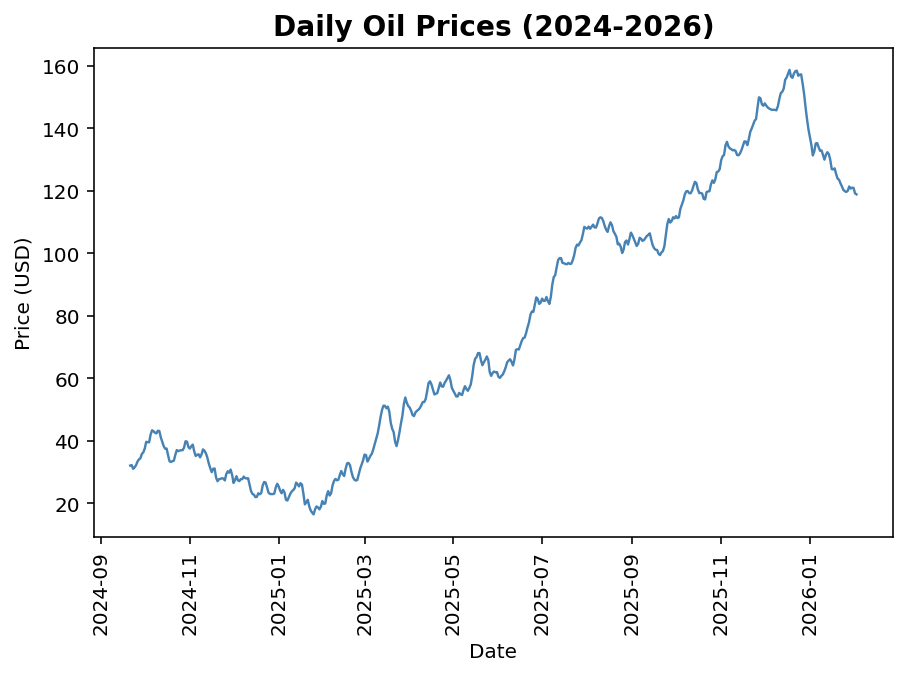

In [ ]:
# ============================================================
# PLOT RAW DATA
# Visualise the original oil price time series
# ============================================================

def plot_raw_series(data, column='price'):
    """
    Plot the raw time series data.

    Parameters:
        data (DataFrame): Input dataframe
        column (str): Column name to plot
    """
    fig, ax = plt.subplots(dpi=144)
    ax.plot(data[column], color='steelblue', linewidth=1.2)
    ax.set_title('Daily Oil Prices (2024-2026)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.set_xlabel('Date')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


plot_raw_series(data, column='price')

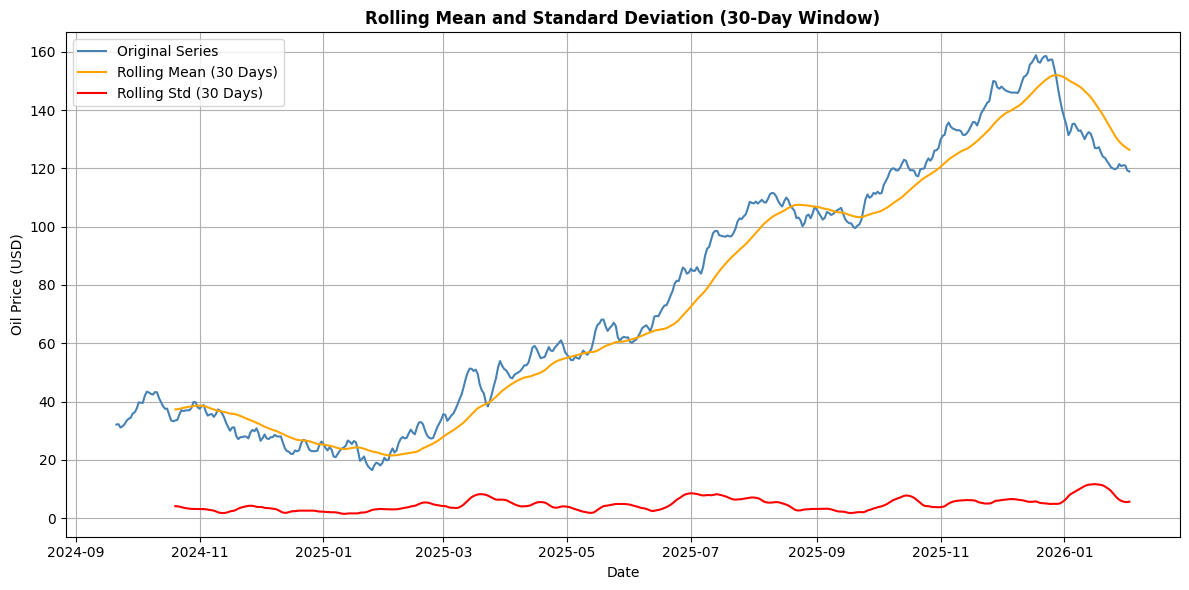

In [ ]:
# ============================================================
# ROLLING STATISTICS
# Rolling mean and std dev to visually confirm non-stationarity
# A stationary series should have constant mean and variance
# ============================================================

def plot_rolling_stats(data, column='price', window=30):
    """
    Plot rolling mean and standard deviation.

    Parameters:
        data (DataFrame): Input dataframe
        column (str): Column to analyse
        window (int): Rolling window size in days
    """
    plt.figure(figsize=(12, 6))
    plt.plot(data[column],                               color='steelblue', label='Original Series')
    plt.plot(data[column].rolling(window=window).mean(), color='orange',    label=f'Rolling Mean ({window} Days)')
    plt.plot(data[column].rolling(window=window).std(),  color='red',       label=f'Rolling Std ({window} Days)')
    plt.title(f'Rolling Mean and Standard Deviation ({window}-Day Window)', fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Oil Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_rolling_stats(data, column='price', window=30)

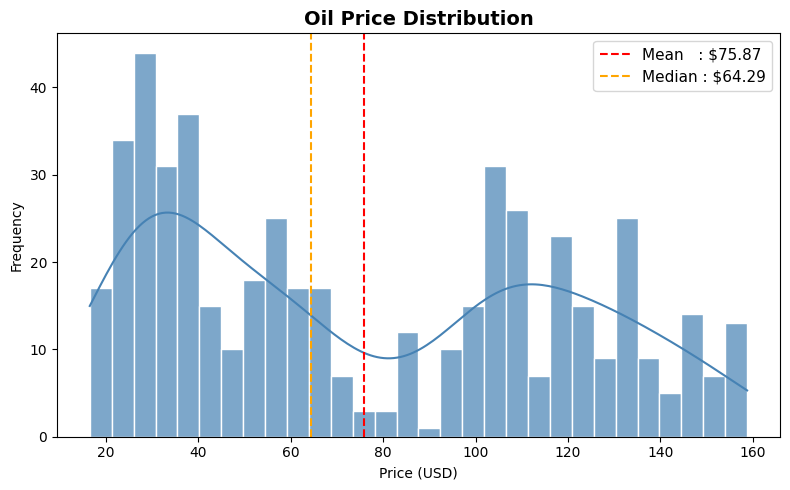

DISTRIBUTION SUMMARY
Mean   : $75.87
Median : $64.29
Std    : $42.91
Min    : $16.48
Max    : $158.78


In [ ]:
# ============================================================
# PRICE DISTRIBUTION
# Histogram shows the distribution of oil prices
# KDE (Kernel Density Estimate) shows the smooth curve
# Right-skewed distribution = more low prices than high
# Normal distribution = prices evenly spread around mean
# ============================================================

def plot_histogram(data, column='price', bins=30):
    """
    Plot histogram with KDE curve to show price distribution.

    Parameters:
        data (DataFrame): Input dataframe
        column (str): Column to plot
        bins (int): Number of histogram bins
    """
    plt.figure(figsize=(8, 5))

    # plot histogram with KDE overlay
    sns.histplot(data[column], bins=bins, color='steelblue',
                 alpha=0.7, edgecolor='white', kde=True)

    # add mean and median lines for reference
    mean_price   = data[column].mean()
    median_price = data[column].median()

    plt.axvline(mean_price,   color='red',    linestyle='--',
                linewidth=1.5, label=f'Mean   : ${mean_price:.2f}')
    plt.axvline(median_price, color='orange', linestyle='--',
                linewidth=1.5, label=f'Median : ${median_price:.2f}')

    plt.title('Oil Price Distribution', fontweight='bold', fontsize=14)
    plt.xlabel('Price (USD)')
    plt.ylabel('Frequency')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

    # print summary statistics
    print('='*40)
    print('DISTRIBUTION SUMMARY')
    print('='*40)
    print(f'Mean   : ${mean_price:.2f}')
    print(f'Median : ${median_price:.2f}')
    print(f'Std    : ${data[column].std():.2f}')
    print(f'Min    : ${data[column].min():.2f}')
    print(f'Max    : ${data[column].max():.2f}')


plot_histogram(data, column='price', bins=30)

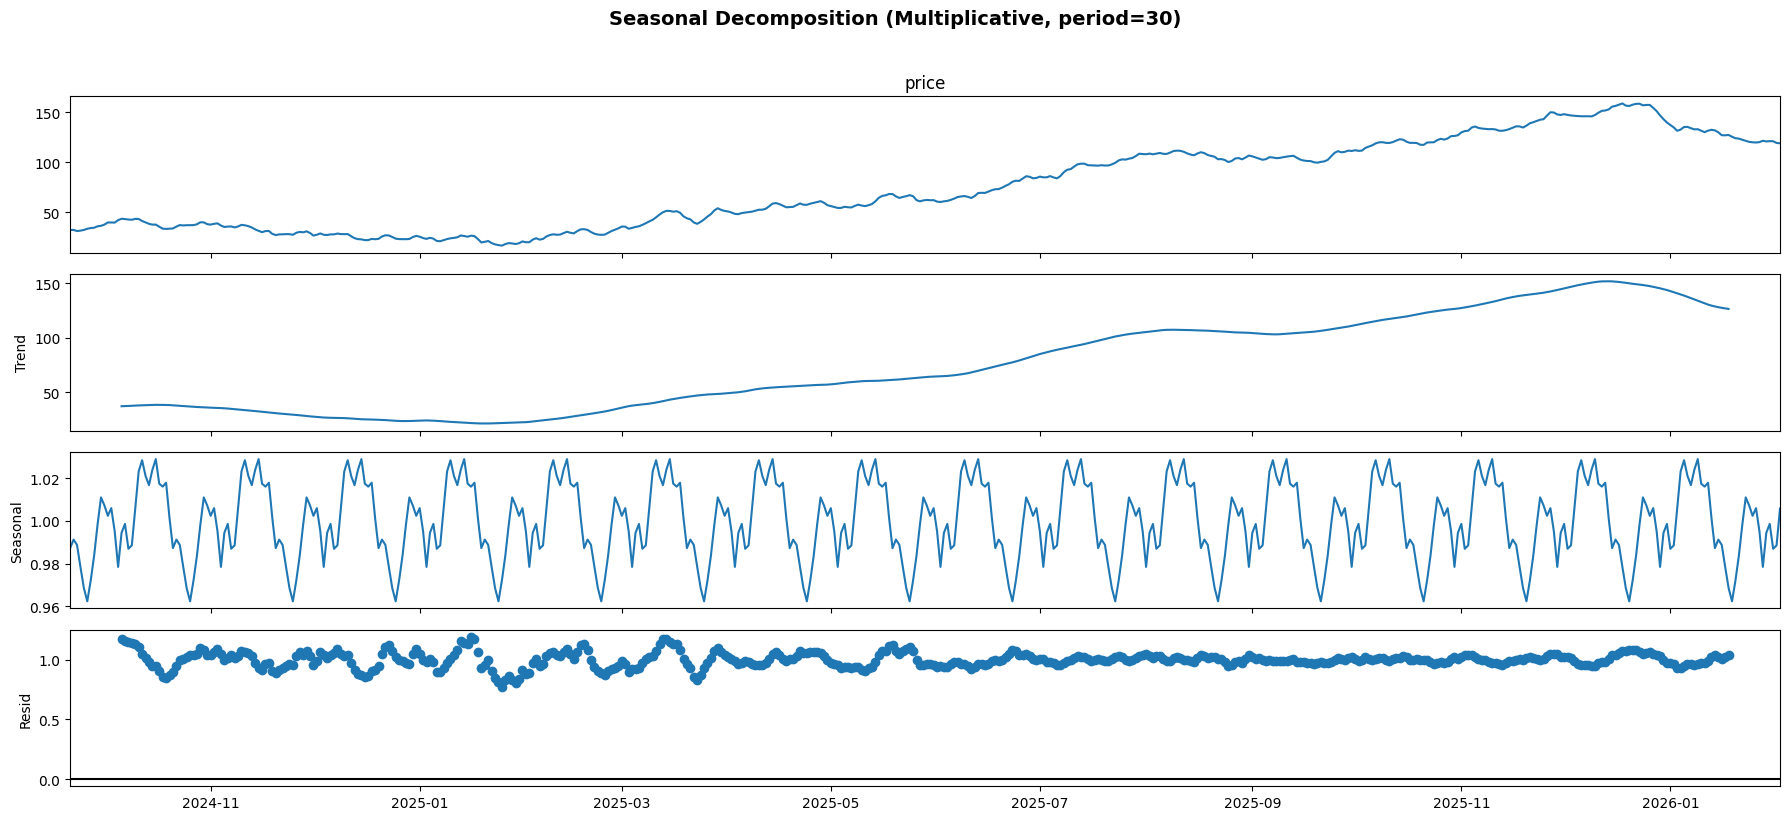

In [ ]:
# ============================================================
# SEASONAL DECOMPOSITION
# Decompose series into: trend, seasonal, residual components
# ============================================================

def plot_decomposition(data, column='price', model='multiplicative', period=30):
    """
    Decompose time series into trend, seasonal and residual.

    Parameters:
        data (DataFrame): Input dataframe
        column (str): Column to decompose
        model (str): 'multiplicative' or 'additive'
        period (int): Seasonal period in days
    """
    rcParams['figure.figsize'] = 18, 8
    decomposition = sm.tsa.seasonal_decompose(data[column], model=model, period=period)
    fig = decomposition.plot()
    plt.suptitle(f'Seasonal Decomposition ({model.capitalize()}, period={period})',
                 fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_decomposition(data, column='price', model='multiplicative', period=30)

**Test for stationary**

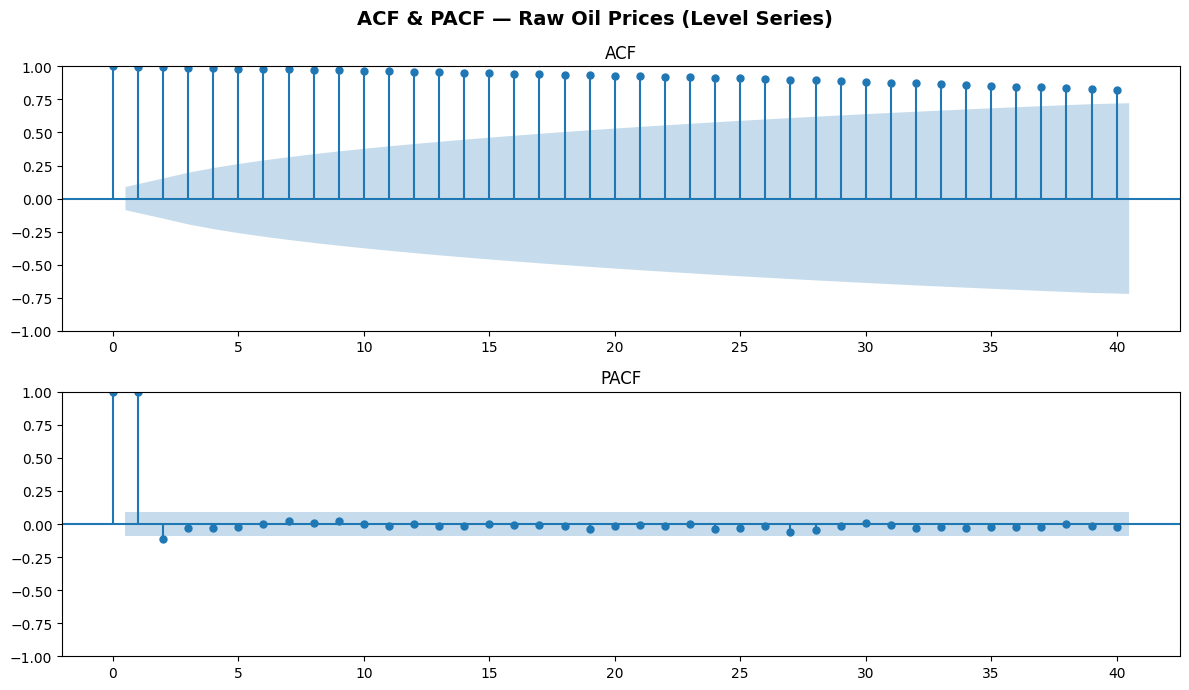

In [ ]:
# ============================================================
# ACF & PACF — RAW SERIES
# Slowly decaying ACF = classic sign of non-stationarity
# ============================================================

def plot_acf_pacf(series, lags=40, title='ACF & PACF'):
    """
    Plot ACF and PACF side by side.

    Parameters:
        series (Series): Time series data
        lags (int): Number of lags to plot
        title (str): Plot title
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plot_acf( series.dropna(), lags=lags, ax=axes[0], title='ACF')
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], title='PACF', method='ywm')
    plt.tight_layout()
    plt.show()


plot_acf_pacf(data['price'], lags=40,
              title='ACF & PACF — Raw Oil Prices (Level Series)')

In [ ]:
# ============================================================
# ADF TEST — RAW DATA
# Test for stationarity before any transformation
# H0: Unit root exists → non-stationary
# H1: No unit root → stationary
# If p-value < 0.05 → reject H0 → stationary
# ============================================================

def run_adf(series, label):
    """
    Run Augmented Dickey-Fuller stationarity test.

    Parameters:
        series (Series): Time series to test
        label (str): Label for print output

    Returns:
        p_value (float): p-value of the ADF test
    """
    result = adfuller(series.dropna())
    print(f'\n{label}')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Lags used     : {result[2]}')
    print(f'  Critical Values:')
    for key, val in result[4].items():
        print(f'    {key}  :  {val:.4f}')
    conclusion = 'STATIONARY (reject H0)' if result[1] < 0.05 else 'NON-STATIONARY (fail to reject H0)'
    print(f'  Conclusion : {conclusion}')
    return result[1]


print('='*55)
print('ADF TEST — Raw Prices')
print('='*55)
run_adf(data['price'], 'Level Series (Raw Prices)')

ADF TEST — Raw Prices

Level Series (Raw Prices)
  ADF Statistic : -0.5462
  p-value       : 0.8827
  Lags used     : 17
  Critical Values:
    1%  :  -3.4440
    5%  :  -2.8676
    10%  :  -2.5700
  Conclusion : NON-STATIONARY (fail to reject H0)


np.float64(0.8826741397403068)

**Log Transformation**

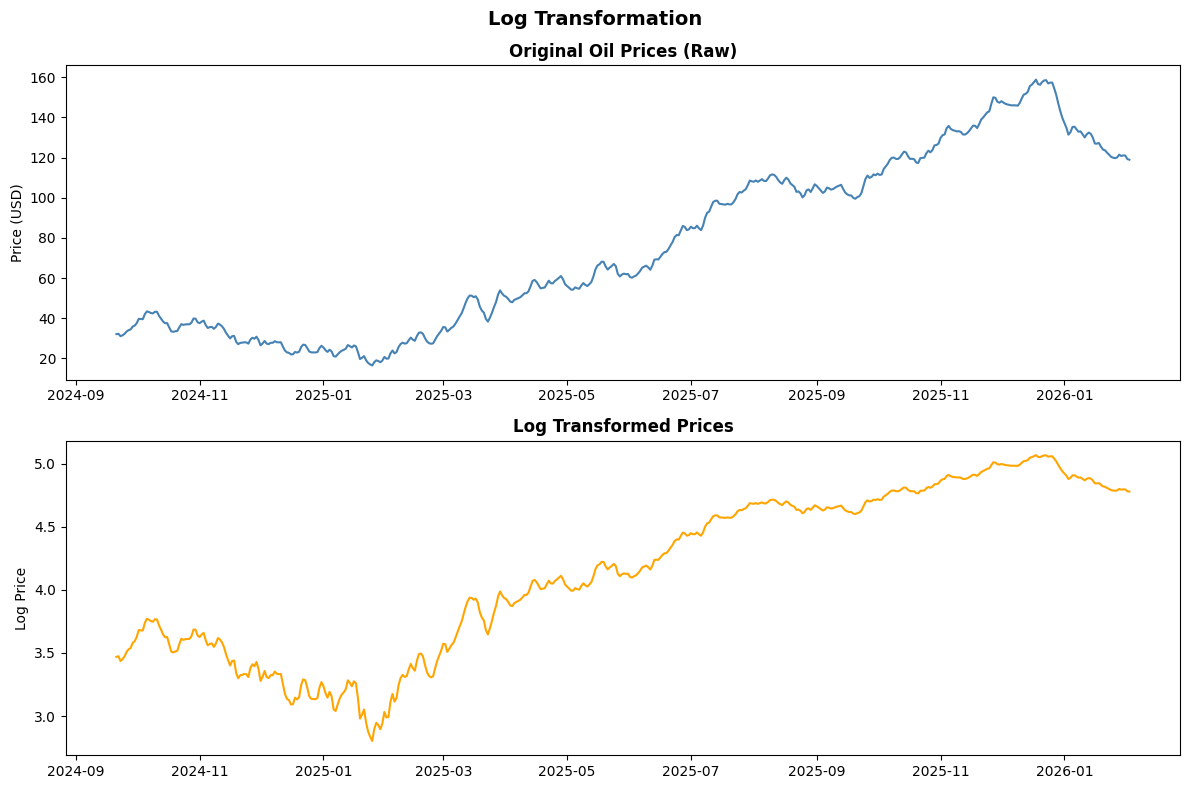

In [ ]:
# ============================================================
# LOG TRANSFORMATION
# Data shows exponential upward trend
# Log transform linearises the trend for better modelling
# After log transform: data range changes from $20-$160 to ~3-5
# ============================================================

def apply_log_transform(data, column='price'):
    """
    Apply log transformation to linearise exponential trend.

    Parameters:
        data (DataFrame): Input dataframe
        column (str): Column to transform

    Returns:
        data (DataFrame): Dataframe with new log column added
    """
    data['data_log'] = np.log(data[column])

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle('Log Transformation', fontsize=14, fontweight='bold')

    axes[0].plot(data[column], color='steelblue')
    axes[0].set_title('Original Oil Prices (Raw)', fontweight='bold')
    axes[0].set_ylabel('Price (USD)')

    axes[1].plot(data['data_log'], color='orange')
    axes[1].set_title('Log Transformed Prices', fontweight='bold')
    axes[1].set_ylabel('Log Price')

    plt.tight_layout()
    plt.show()

    return data


data = apply_log_transform(data, column='price')

**First Difference**

In [ ]:
# ============================================================
# FIRST DIFFERENCE
# Take first difference of log transformed data
# This removes the trend to make the series stationary
# data_tr_1 = log(price_t) - log(price_t-1)
# ============================================================

# take first difference of log transformed data
data['data_tr_1'] = data['data_log'].diff()

# preview the new columns
data.head(10)

,price,data_log,data_tr_1
date,,,
2024-09-21,32.10,3.468856,NaN
2024-09-22,32.25,3.473518,0.004662
2024-09-23,31.07,3.436243,-0.037275
2024-09-24,31.50,3.449988,0.013745
2024-09-25,32.21,3.472277,0.022289
2024-09-26,33.38,3.507957,0.035680
2024-09-27,34.08,3.528711,0.020754
2024-09-28,34.43,3.538928,0.010218
2024-09-29,35.83,3.578786,0.039857


**Plotting after Log transformation and first differencing**

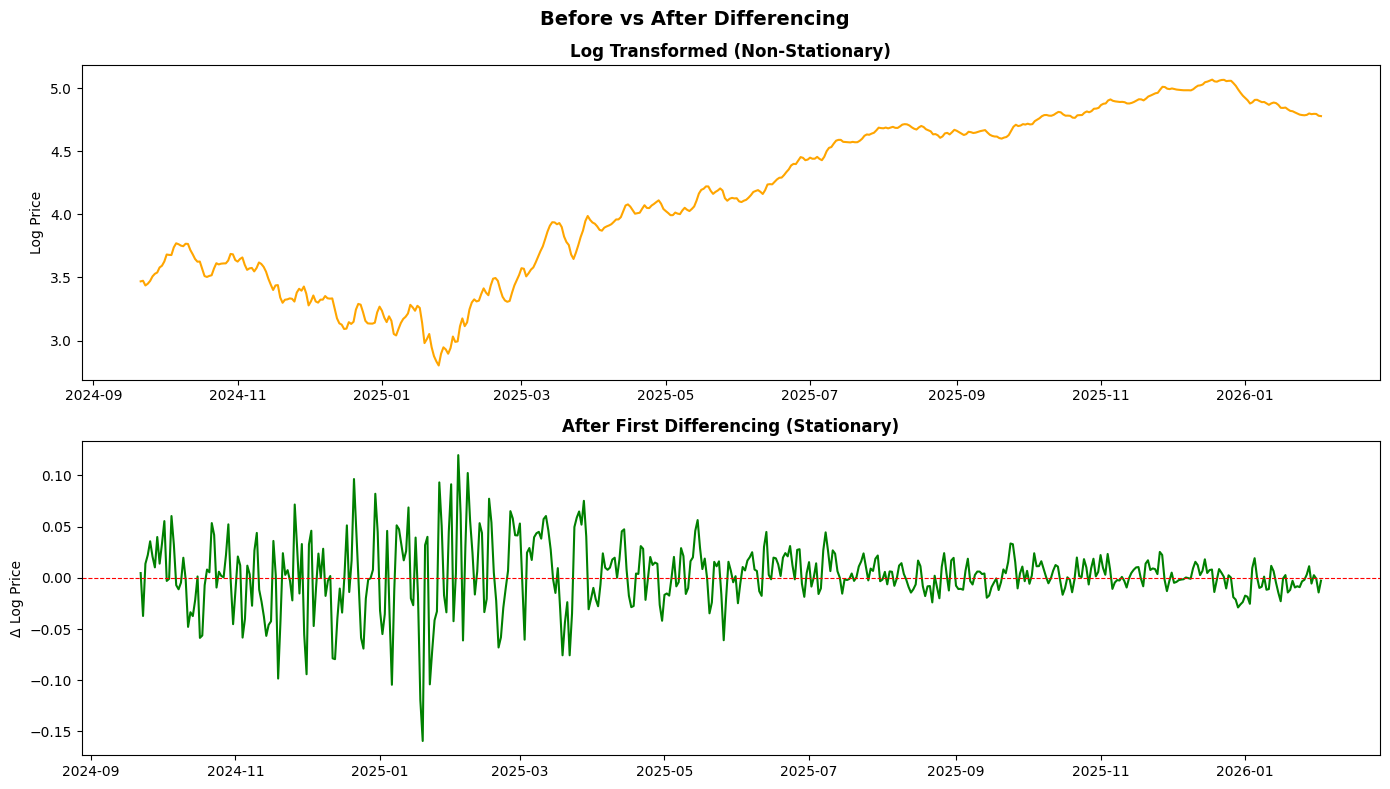

In [ ]:
# ============================================================
# PLOT DIFFERENCED DATA
# After log + differencing, series should fluctuate around 0
# This confirms the trend has been removed
# ============================================================

def plot_differenced(data, column='data_tr_1'):
    """
    Plot the differenced time series.

    Parameters:
        data (DataFrame): Input dataframe
        column (str): Differenced column to plot
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle('Before vs After Differencing', fontsize=14, fontweight='bold')

    axes[0].plot(data['data_log'], color='orange')
    axes[0].set_title('Log Transformed (Non-Stationary)', fontweight='bold')
    axes[0].set_ylabel('Log Price')

    axes[1].plot(data[column], color='green')
    axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[1].set_title('After First Differencing (Stationary)', fontweight='bold')
    axes[1].set_ylabel('Δ Log Price')

    plt.tight_layout()
    plt.show()


plot_differenced(data, column='data_tr_1')

**Stationary Test**

In [ ]:
# ============================================================
# ADF TEST — LOG + DIFFERENCED DATA
# Confirm stationarity after transformation
# Expect p-value < 0.05 → stationary
# ============================================================

print('='*55)
print('ADF TEST — Log Transformed + First Difference')
print('='*55)
run_adf(data['data_tr_1'][1:], 'Log + First Difference')

ADF TEST — Log Transformed + First Difference

Log + First Difference
  ADF Statistic : -6.3410
  p-value       : 0.0000
  Lags used     : 13
  Critical Values:
    1%  :  -3.4439
    5%  :  -2.8675
    10%  :  -2.5700
  Conclusion : STATIONARY (reject H0)


np.float64(2.754898539913133e-08)

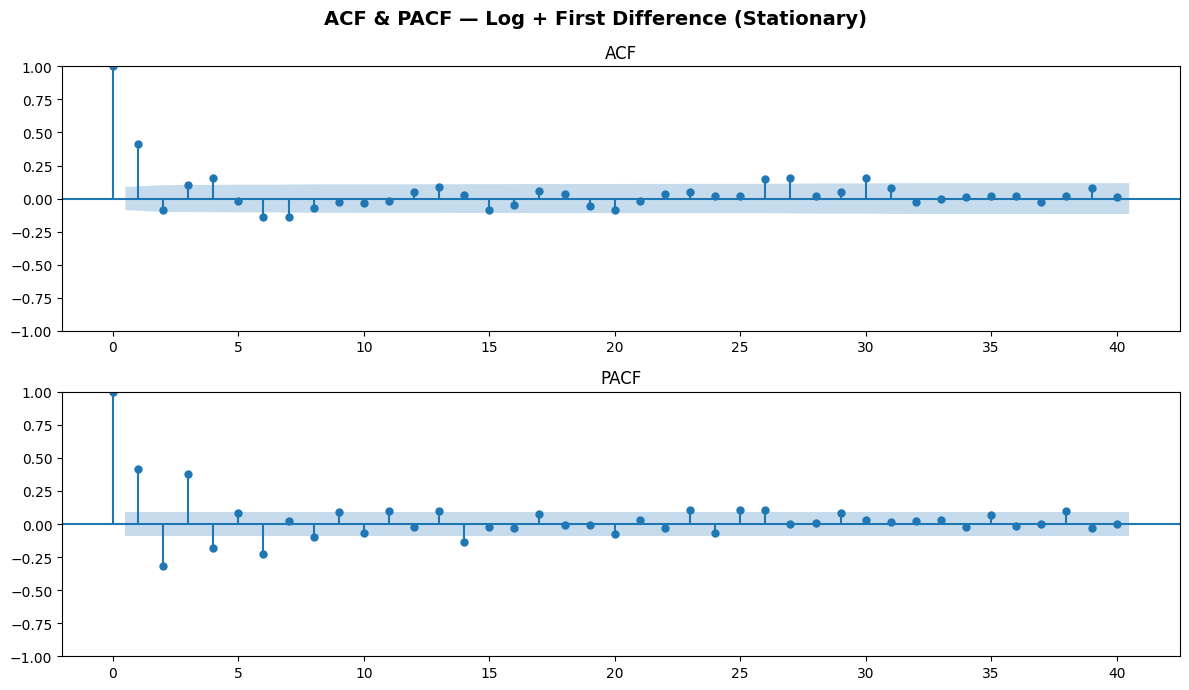

In [ ]:
# ============================================================
# ACF & PACF — STATIONARY SERIES
# After differencing, ACF should cut off quickly
# This confirms stationarity and helps identify p, q values
# ============================================================

plot_acf_pacf(data['data_tr_1'][1:], lags=40,
              title='ACF & PACF — Log + First Difference (Stationary)')

**Defining Arma Model**

In [ ]:
# ============================================================
# INITIAL ARMA MODEL (d=0)
# Test run with ARIMA(3,0,3) on differenced data
# This is just to verify the code works before grid search
# ============================================================

# fit initial model on differenced data as a test
model     = ARIMA(data['data_tr_1'][1:], order=(3, 0, 3))
model_fit = model.fit()
aic       = model_fit.aic

print(f'ARIMA(3,0,3) AIC: {aic:.4f}')
print(model_fit.summary())

ARIMA(3,0,3) AIC: -2351.0245
                               SARIMAX Results                                
Dep. Variable:              data_tr_1   No. Observations:                  499
Model:                 ARIMA(3, 0, 3)   Log Likelihood                1183.512
Date:                Wed, 11 Mar 2026   AIC                          -2351.025
Time:                        00:57:48   BIC                          -2317.324
Sample:                    09-22-2024   HQIC                         -2337.799
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0027      0.002      1.207      0.227      -0.002       0.007
ar.L1          0.8903      0.091      9.768      0.000       0.712       1.069
ar.L2         -0.6355  

**Grid Search**

In [ ]:
# ============================================================
# GRID SEARCH — BEST p, d, q VIA AIC
# Loop over all combinations as required by assignment:
#   p = [0, 8] — AR order
#   d = [0, 2] — differencing order
#   q = [0, 8] — MA order
# Total = 9 x 3 x 9 = 243 models
# Grid search runs on RAW data — ARIMA handles differencing
# When d=0 → ARIMA reduces to pure ARMA model
# Best model = lowest AIC
# ============================================================

def optimize_ARIMA(data, order_list):
    """
    Grid search over all ARIMA(p,d,q) combinations.
    Fits each model and records AIC value.
    Returns results sorted by AIC ascending (best first).

    Parameters:
        data (Series): Raw time series data
        order_list (list): List of (p,d,q) tuples to try

    Returns:
        result_df (DataFrame): Results sorted by AIC
    """
    results = []

    for order in tqdm_notebook(order_list):
        try:
            # fit ARIMA model with current p,d,q
            model     = ARIMA(data, order=order)
            model_fit = model.fit()
            aic       = model_fit.aic
            results.append([order, aic])
        except:
            # some combinations fail to converge — store None
            results.append([order, None])

    # create results dataframe sorted by AIC ascending
    result_df = pd.DataFrame(results, columns=['(p, d, q)', 'AIC'])
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df


# define search ranges as required by assignment
p_values   = range(0, 9)   # p = [0, 8]
d_values   = range(0, 3)   # d = [0, 2]
q_values   = range(0, 9)   # q = [0, 8]

order_list = list(product(p_values, d_values, q_values))

# run grid search on RAW prices — ARIMA handles differencing internally
result_df  = optimize_ARIMA(data['price'], order_list)

# display top 10 — lowest AIC is best model
print('Top 10 Models by AIC (lowest = best):')
result_df.head(10)

  0%|          | 0/243 [00:00<?, ?it/s]

Top 10 Models by AIC (lowest = best):


,"(p, d, q)",AIC
0,"(2, 2, 7)",1429.357099
1,"(4, 1, 5)",1429.772199
2,"(0, 1, 5)",1429.897917
3,"(1, 1, 4)",1430.457760
4,"(2, 1, 4)",1430.851612
5,"(5, 1, 5)",1430.951089
6,"(4, 1, 1)",1431.110534
7,"(4, 1, 8)",1431.194639
8,"(0, 1, 6)",1431.355376
9,"(3, 1, 3)",1431.692968


**Fit Best Model**

In [ ]:
# ============================================================
# FIT BEST MODEL
# Extract best p,d,q from grid search results
# Refit on raw data for forecasting
# ============================================================

# extract best p, d, q — row 0 has lowest AIC
best_p, best_d, best_q = result_df.iloc[0]['(p, d, q)']

print(f'Best Model  : ARIMA({best_p},{best_d},{best_q})')
print(f'Best AIC    : {result_df.iloc[0]["AIC"]:.4f}')

# fit best model on RAW prices
best_model     = ARIMA(data['price'], order=(best_p, best_d, best_q))
best_model_fit = best_model.fit()

print(best_model_fit.summary())

Best Model  : ARIMA(2,2,7)
Best AIC    : 1429.3571
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  500
Model:                 ARIMA(2, 2, 7)   Log Likelihood                -704.679
Date:                Wed, 11 Mar 2026   AIC                           1429.357
Time:                        01:03:17   BIC                           1471.463
Sample:                    09-21-2024   HQIC                          1445.882
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1824      0.032    -36.884      0.000      -1.245      -1.120
ar.L2         -0.9175      0.032    -28.331      0.000      -0.981      -0.854
m

** Residual Diagnostics**

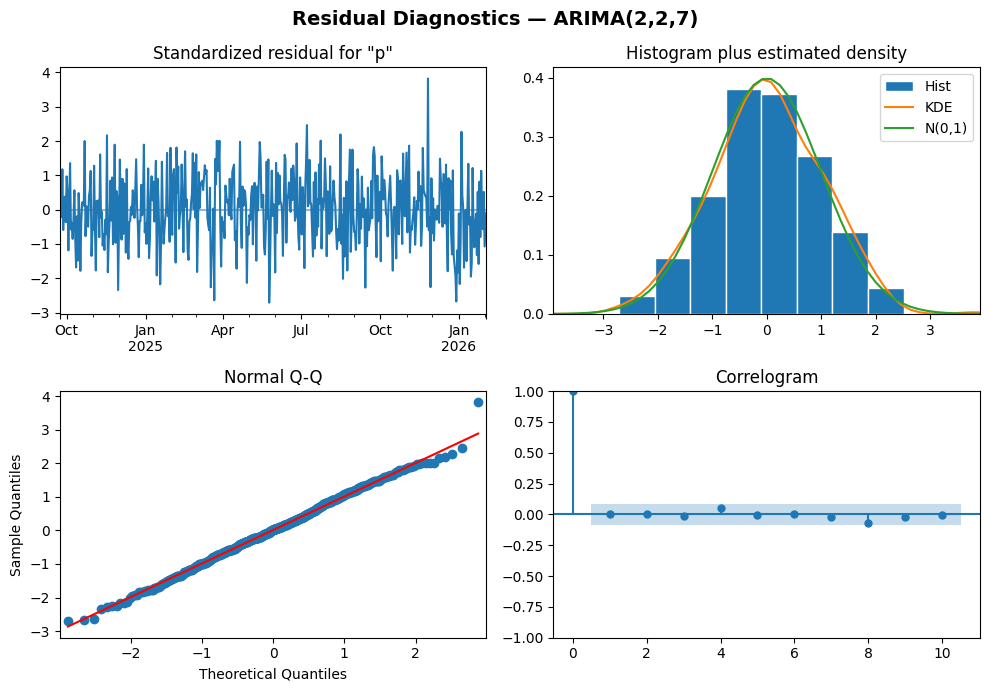

In [ ]:
# ============================================================
# RESIDUAL DIAGNOSTICS
# A well-fitted model should have residuals that are:
#   1. White noise — no autocorrelation remaining
#   2. Normally distributed — bell curve shape
#   3. Mean ≈ 0 — no systematic bias
# statsmodels plot_diagnostics shows all 4 checks at once
# ============================================================

best_model_fit.plot_diagnostics(figsize=(10, 7))
plt.suptitle(f'Residual Diagnostics — ARIMA({best_p},{best_d},{best_q})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Residuals Plot**

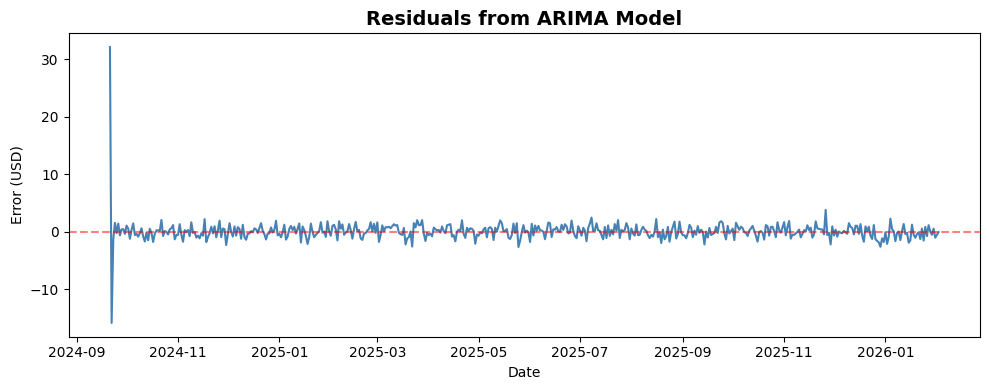

In [ ]:
# ============================================================
# RESIDUALS vs DATA
# Compare model predictions against actual prices
# Residuals should fluctuate randomly around 0
# ============================================================

def plot_residuals(data, best_model_fit, column='price'):
    """
    Calculate and plot model residuals.

    Parameters:
        data (DataFrame): Input dataframe
        best_model_fit: Fitted ARIMA model
        column (str): Column name of actual prices

    Returns:
        predictions (Series): Model predictions
        residuals (Series): Residuals (actual - predicted)
    """
    pred_start_date = data[column].index[0]
    pred_end_date   = data[column].index[-1]

    predictions = best_model_fit.predict(start=pred_start_date, end=pred_end_date)
    residuals   = data[column] - predictions

    plt.figure(figsize=(10, 4))
    plt.plot(residuals, color='steelblue')
    plt.axhline(0, color='r', linestyle='--', alpha=0.5)
    plt.title('Residuals from ARIMA Model', fontsize=14, fontweight='bold')
    plt.ylabel('Error (USD)')
    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()

    return predictions, residuals


predictions, residuals = plot_residuals(data, best_model_fit, column='price')

** ACF of Residuals + Distribution**

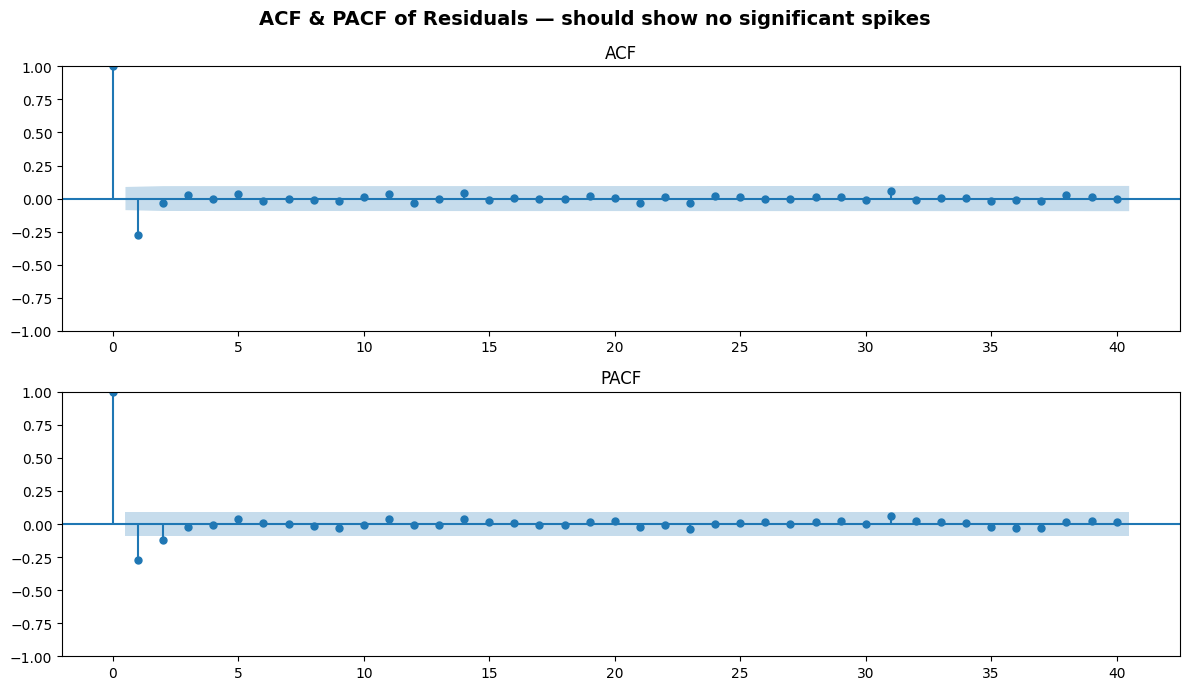

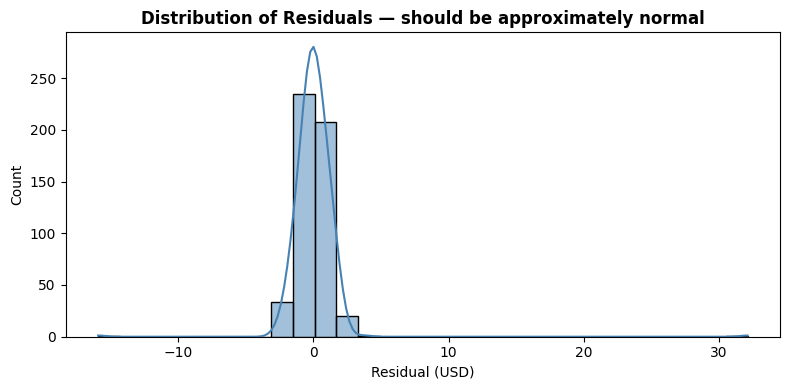

In [ ]:
# ============================================================
# ACF OF RESIDUALS + DISTRIBUTION
# If model is well-fitted:
#   ACF should show no significant spikes → white noise
#   Distribution should be approximately normal
# ============================================================

# ACF of residuals — check for remaining autocorrelation
plot_acf_pacf(residuals, lags=40,
              title='ACF & PACF of Residuals — should show no significant spikes')

# distribution of residuals — check for normality
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=30, kde=True, color='steelblue')
plt.title('Distribution of Residuals — should be approximately normal',
          fontweight='bold')
plt.xlabel('Residual (USD)')
plt.tight_layout()
plt.show()

**Model Performance(RMSE)**

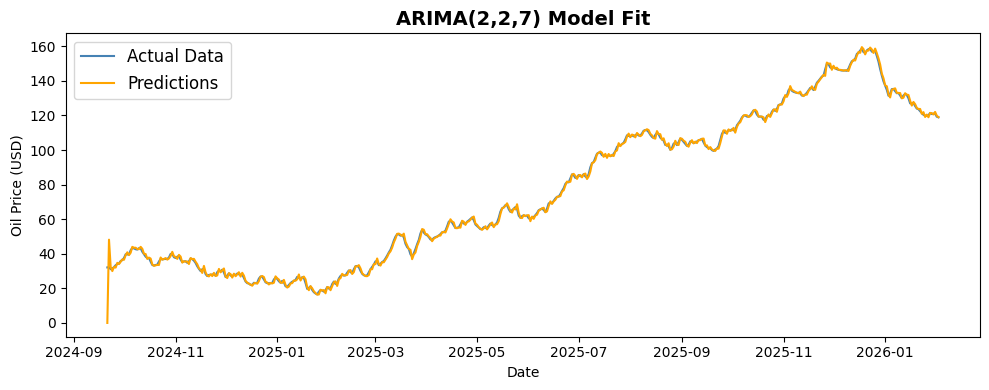

Root Mean Squared Error (RMSE): 1.8850


In [ ]:
# ============================================================
# MODEL PERFORMANCE — RMSE
# Root Mean Squared Error measures average prediction error
# Lower RMSE = better model fit
# Plot shows how well model fits the historical data
# ============================================================

def calculate_rmse(data, predictions, residuals, best_p, best_d, best_q, column='price'):
    """
    Calculate RMSE and plot model fit vs actual data.

    Parameters:
        data (DataFrame): Input dataframe
        predictions (Series): Model predictions
        residuals (Series): Model residuals
        best_p, best_d, best_q (int): Best ARIMA parameters
        column (str): Column name of actual prices

    Returns:
        rmse (float): Root Mean Squared Error
    """
    # plot actual vs predicted
    plt.figure(figsize=(10, 4))
    plt.plot(data[column], label='Actual Data',  color='steelblue')
    plt.plot(predictions,  label='Predictions',  color='orange')
    plt.title(f'ARIMA({best_p},{best_d},{best_q}) Model Fit',
              fontsize=14, fontweight='bold')
    plt.ylabel('Oil Price (USD)')
    plt.xlabel('Date')
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    # calculate RMSE
    rmse = np.sqrt(np.mean(residuals**2))
    print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
    return rmse


rmse = calculate_rmse(data, predictions, residuals, best_p, best_d, best_q)

**24-Month Forecast**

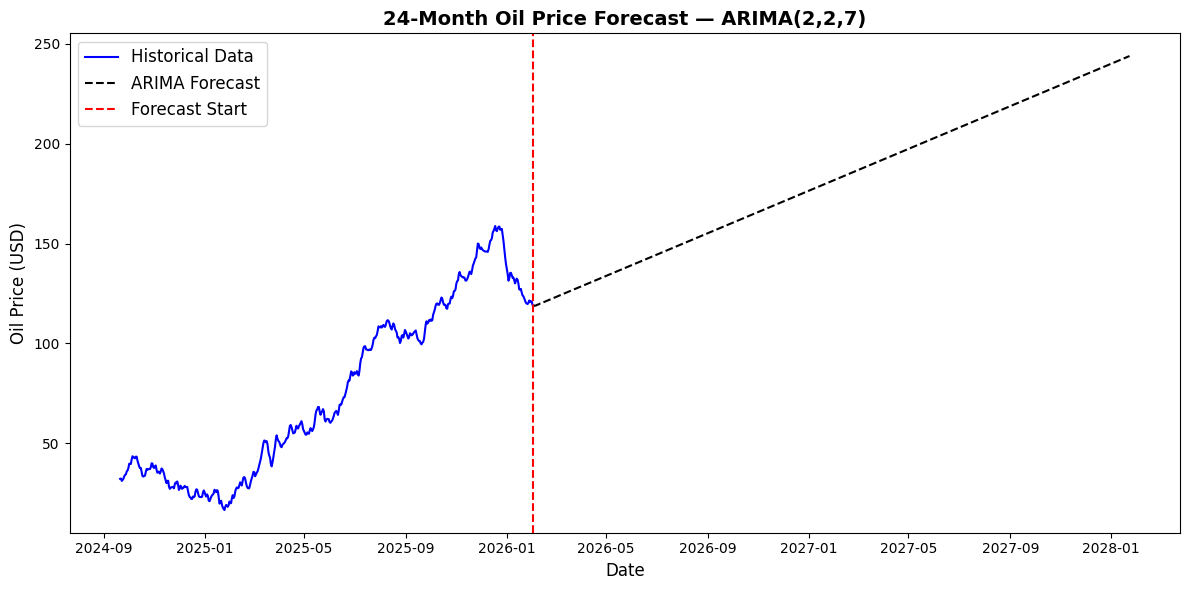

Last known price : $118.92
Forecast end     : $243.94


In [ ]:
# ============================================================
# 24-MONTH FORECAST
# Uses get_prediction() to carry trend momentum forward
# ============================================================

def plot_forecast(data, best_model_fit, best_p, best_d, best_q,
                  n_forecast=24*30, column='price'):
    """
    Generate and plot 24-month forecast.

    Parameters:
        data (DataFrame): Input dataframe
        best_model_fit: Fitted ARIMA model
        best_p, best_d, best_q (int): Best ARIMA parameters
        n_forecast (int): Number of steps to forecast
        column (str): Column name of actual prices
    """
    # generate forecast using get_prediction()
    predict = best_model_fit.get_prediction(
        end=best_model_fit.nobs + n_forecast
    )

    forecast_values = predict.predicted_mean[-n_forecast:]

    # create future date index starting from last known date
    last_date      = data[column].index[-1]
    future_dates   = pd.date_range(start=last_date,
                                   periods=n_forecast + 1, freq='D')[1:]

    # connect last real data point to forecast for smooth plot
    connect_dates  = pd.DatetimeIndex([last_date]).append(future_dates)
    connect_values = np.append(data[column].iloc[-1], forecast_values.values)

    # plot
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(data[column], color='blue',  label='Historical Data')
    ax.plot(connect_dates, connect_values, 'k--', label='ARIMA Forecast')
    ax.axvline(last_date, color='red', linestyle='--',
               linewidth=1.5, label='Forecast Start')
    ax.set_title(f'24-Month Oil Price Forecast — ARIMA({best_p},{best_d},{best_q})',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Oil Price (USD)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f'Last known price : ${data[column].iloc[-1]:.2f}')
    print(f'Forecast end     : ${forecast_values.values[-1]:.2f}')


plot_forecast(data, best_model_fit, best_p, best_d, best_q, n_forecast=24*30)

**Forecast with confidence intervals**

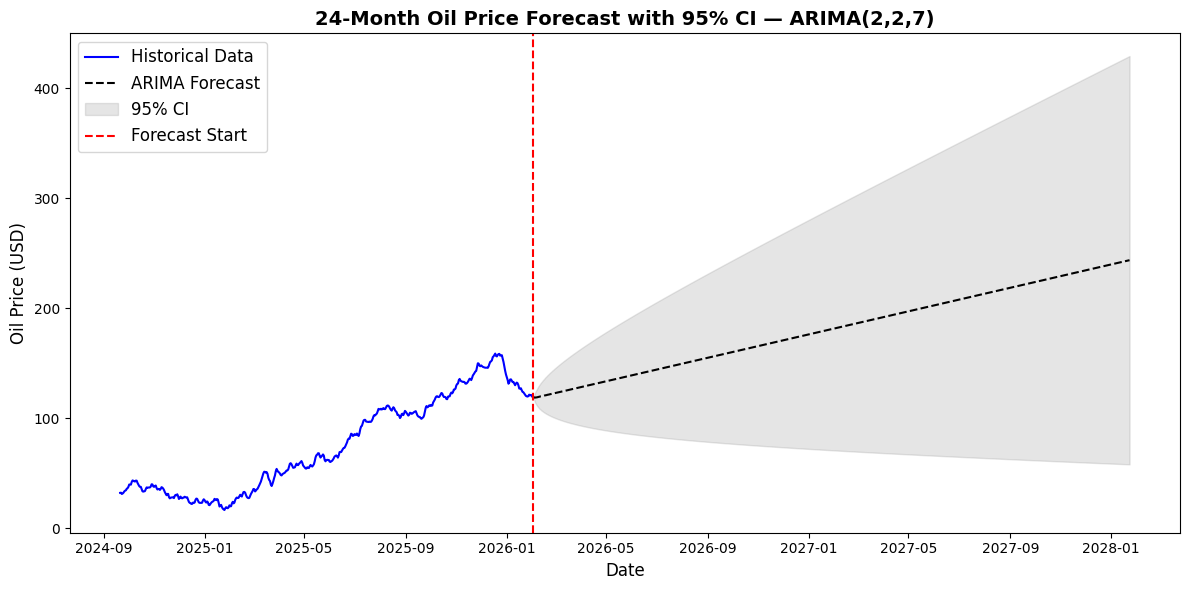

Last known price : $118.92
Forecast end     : $243.76
95% CI end       : [58.04, 429.49]


In [ ]:
# ============================================================
# 24-MONTH FORECAST — CONFIDENCE INTERVALS
# yhat_lower = lower 95% CI
# yhat_upper = upper 95% CI
# CI widens over time — reflects increasing uncertainty
# ============================================================

def plot_forecast_ci(data, best_model_fit, best_p, best_d, best_q,
                     n_forecast=24*30, column='price'):
    """
    Generate and plot 24-month forecast with confidence intervals.

    Parameters:
        data (DataFrame): Input dataframe
        best_model_fit: Fitted ARIMA model
        best_p, best_d, best_q (int): Best ARIMA parameters
        n_forecast (int): Number of steps to forecast
        column (str): Column name of actual prices
    """
    # generate forecast with confidence intervals
    forecast_obj  = best_model_fit.get_forecast(steps=n_forecast)
    forecast_mean = forecast_obj.predicted_mean
    forecast_ci   = forecast_obj.conf_int(alpha=0.05)

    # create future date index
    last_date    = data[column].index[-1]
    future_dates = pd.date_range(start=last_date,
                                 periods=n_forecast + 1, freq='D')[1:]

    # connect last real data point to forecast
    connect_dates  = pd.DatetimeIndex([last_date]).append(future_dates)
    connect_mean   = np.append(data[column].iloc[-1], forecast_mean.values)
    connect_lower  = np.append(data[column].iloc[-1], forecast_ci.iloc[:, 0].values)
    connect_upper  = np.append(data[column].iloc[-1], forecast_ci.iloc[:, 1].values)

    # plot
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(data[column], color='blue', label='Historical Data')
    ax.plot(connect_dates, connect_mean,
            color='black', linestyle='--', label='ARIMA Forecast')
    ax.fill_between(connect_dates,
                    connect_lower,
                    connect_upper,
                    color='grey', alpha=0.2, label='95% CI')
    ax.axvline(last_date, color='red', linestyle='--',
               linewidth=1.5, label='Forecast Start')

    ax.set_title(f'24-Month Oil Price Forecast with 95% CI — ARIMA({best_p},{best_d},{best_q})',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Oil Price (USD)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f'Last known price : ${data[column].iloc[-1]:.2f}')
    print(f'Forecast end     : ${forecast_mean.values[-1]:.2f}')
    print(f'95% CI end       : [{forecast_ci.iloc[-1, 0]:.2f}, '
          f'{forecast_ci.iloc[-1, 1]:.2f}]')


plot_forecast_ci(data, best_model_fit, best_p, best_d, best_q, n_forecast=24*30)

**LSTM Imports**

In [ ]:
# ============================================================
# LSTM IMPORTS
# Deep learning libraries for LSTM model
# ============================================================
# Upgrading Keras and TensorFlow to ensure compatibility.
!pip install keras tensorflow --upgrade -qq

from math import sqrt
from numpy import concatenate
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.callbacks import EarlyStopping

print('LSTM libraries loaded successfully ✓')


LSTM libraries loaded successfully ✓


**Preparing LSTM data**

In [ ]:
# ============================================================
# PREPARE DATA FOR LSTM — 60 DAY LOOKBACK
# Looking back 60 days
# This allows LSTM to see the full upward trend
# and not just the last price drop
# ============================================================

def prepare_lstm_data(data, column='price', lookback=60):
    """
    Prepare time series data for LSTM model.
    Uses lookback window so LSTM sees full trend history.

    Parameters:
        data (DataFrame): Input dataframe
        column (str): Column to model
        lookback (int): Number of past days to look back

    Returns:
        scaler: Fitted scaler for inverse transform
        train_X, train_y: Training data
        test_X, test_y: Test data
        n_train (int): Number of training samples
    """
    # extract price values and reshape to 2D
    values = data[column].values.reshape(-1, 1).astype('float32')

    # normalise to range [0, 1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(values)

    # convert to supervised learning format
    # X = last 60 prices, y = next price
    X, y = [], []
    for i in range(lookback, len(scaled)):
        X.append(scaled[i-lookback:i, 0])  # last 60 prices
        y.append(scaled[i, 0])             # next price

    X = np.array(X)
    y = np.array(y)

    # split into train (80%) and test (20%)
    n_train = int(len(X) * 0.8)
    train_X = X[:n_train]
    train_y = y[:n_train]
    test_X  = X[n_train:]
    test_y  = y[n_train:]

    # reshape to 3D for LSTM: [samples, timesteps, features]
    train_X = train_X.reshape((train_X.shape[0], lookback, 1))
    test_X  = test_X.reshape((test_X.shape[0],  lookback, 1))

    print(f'Lookback window  : {lookback} days')
    print(f'Training samples : {train_X.shape[0]}')
    print(f'Test samples     : {test_X.shape[0]}')
    print(f'Input shape      : {train_X.shape}')

    return scaler, train_X, train_y, test_X, test_y, n_train


scaler, train_X, train_y, test_X, test_y, n_train = prepare_lstm_data(
    data, column='price', lookback=60
)

Lookback window  : 60 days
Training samples : 352
Test samples     : 88
Input shape      : (352, 60, 1)


**Building and Training LSTM**

In [ ]:
# ============================================================
# BUILD & TRAIN LSTM MODEL
# Updated input shape to match 60 day lookback
# Added learning rate tuning via Adam optimizer
# ============================================================

from keras.optimizers import Adam

def build_lstm_model(train_X, train_y, test_X, test_y,
                     epochs=50, batch_size=32, learning_rate=0.001):
    """
    Build and train LSTM model with tunable learning rate.

    Parameters:
        train_X, train_y: Training data
        test_X, test_y: Validation data
        epochs (int): Maximum training epochs
        batch_size (int): Batch size for training
        learning_rate (float): Adam optimizer learning rate

    Returns:
        model: Trained LSTM model
        history: Training history
    """
    model = Sequential()

    # first LSTM layer
    model.add(LSTM(50, return_sequences=True,
                   input_shape=(train_X.shape[1], train_X.shape[2])))
    model.add(Dropout(0.2))

    # second LSTM layer
    model.add(LSTM(50, return_sequences=False))
    model.add(Dropout(0.2))

    # output layer
    model.add(Dense(1))

    # compile with tunable learning rate
    model.compile(loss='mae', optimizer=Adam(learning_rate=learning_rate))

    # early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10,
                               restore_best_weights=True)

    history = model.fit(
        train_X, train_y,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(test_X, test_y),
        callbacks=[early_stop],
        verbose=1,
        shuffle=False
    )

    return model, history


lstm_model, history = build_lstm_model(
    train_X, train_y, test_X, test_y,
    epochs=50, batch_size=32, learning_rate=0.001
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0869 - val_loss: 0.0730
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1657 - val_loss: 0.2997
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0672 - val_loss: 0.0523
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0797 - val_loss: 0.0800
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0614 - val_loss: 0.0456
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0427 - val_loss: 0.0444
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0464 - val_loss: 0.0552
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0489 - val_loss: 0.0437
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0465 - val_loss: 0.0521
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0574 - val_loss: 0.0689
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0531 - val_loss: 0.0617
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0

**Training History**

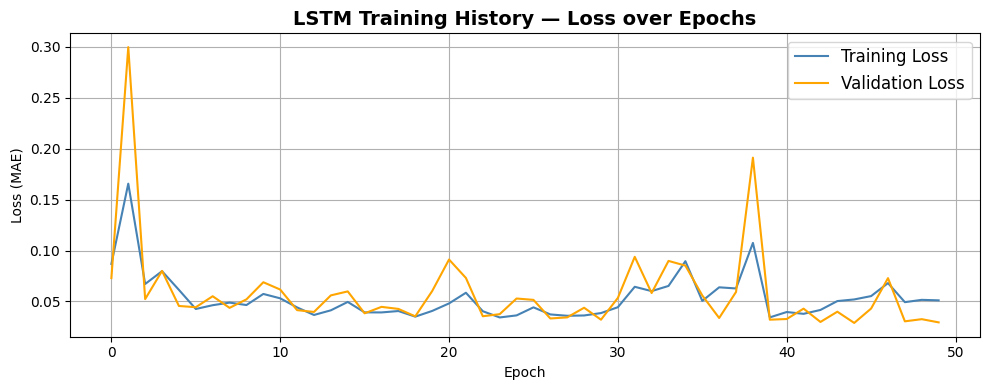

Final training loss   : 0.051115
Final validation loss : 0.029509


In [ ]:
# ============================================================
# PLOT TRAINING HISTORY
# Shows how training and validation loss changed over epochs
# Both lines should decrease and converge
# Large gap between lines = overfitting
# ============================================================

def plot_training_history(history):
    """
    Plot training and validation loss over epochs.

    Parameters:
        history: Keras training history object
    """
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('LSTM Training History — Loss over Epochs',
              fontsize=14, fontweight='bold')
    plt.ylabel('Loss (MAE)')
    plt.xlabel('Epoch')
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f'Final training loss   : {history.history["loss"][-1]:.6f}')
    print(f'Final validation loss : {history.history["val_loss"][-1]:.6f}')


plot_training_history(history)

**Evaluating LSTM**

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
LSTM MODEL EVALUATION
RMSE : 5.1733
MAE  : 4.1205


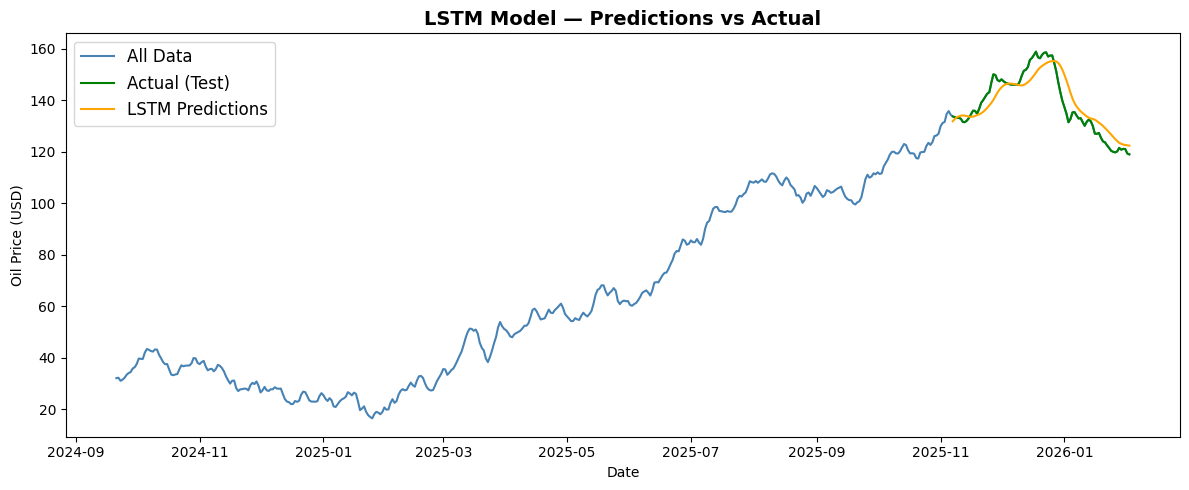

In [ ]:
# ============================================================
# LSTM PREDICTIONS & EVALUATION
# Make predictions on test data
# Invert MinMaxScaler to get back original USD price scale
# Evaluate using RMSE and MAE
# ============================================================

def evaluate_lstm(data, lstm_model, scaler, test_X, test_y,
                  n_train, lookback=60, column='price'):
    """
    Generate predictions and evaluate LSTM model performance.

    Parameters:
        data (DataFrame): Original dataframe
        lstm_model: Trained LSTM model
        scaler (MinMaxScaler): Fitted scaler
        test_X, test_y: Test data
        n_train (int): Number of training samples
        lookback (int): Lookback window size
        column (str): Column name

    Returns:
        inv_yhat (array): Predictions in original scale
        inv_y (array): Actual values in original scale
        rmse (float): RMSE score
    """
    # make predictions on test data
    yhat = lstm_model.predict(test_X)

    # invert normalisation to get back original price scale
    inv_yhat = scaler.inverse_transform(yhat)
    inv_y    = scaler.inverse_transform(test_y.reshape(-1, 1))

    # calculate evaluation metrics
    rmse = sqrt(mean_squared_error(inv_y, inv_yhat))
    mae  = mean_absolute_error(inv_y, inv_yhat)

    print('='*45)
    print('LSTM MODEL EVALUATION')
    print('='*45)
    print(f'RMSE : {rmse:.4f}')
    print(f'MAE  : {mae:.4f}')

    # calculate test dates correctly using lookback offset
    test_dates = data[column].index[lookback + n_train: lookback + n_train + len(inv_y)]

    plt.figure(figsize=(12, 5))
    plt.plot(data[column].index, data[column].values,
             color='steelblue', label='All Data')
    plt.plot(test_dates, inv_y,    color='green',
             label='Actual (Test)')
    plt.plot(test_dates, inv_yhat, color='orange',
             label='LSTM Predictions')
    plt.title('LSTM Model — Predictions vs Actual',
              fontsize=14, fontweight='bold')
    plt.ylabel('Oil Price (USD)')
    plt.xlabel('Date')
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    return inv_yhat, inv_y, rmse


inv_yhat, inv_y, lstm_rmse = evaluate_lstm(data, lstm_model, scaler,
                                            test_X, test_y, n_train,
                                            lookback=60)

**Hyperparameter Tuning**

In [ ]:
# ============================================================
# HYPERPARAMETER TUNING
# Test different combinations of:
#   units         — LSTM memory capacity
#   batch_size    — samples per gradient update
#   learning_rate — how fast model learns
# Select best model based on lowest validation loss
# ============================================================

def tune_lstm(train_X, train_y, test_X, test_y):
    """
    Tune LSTM hyperparameters — units, batch size, learning rate.

    Parameters:
        train_X, train_y: Training data
        test_X, test_y: Validation data

    Returns:
        best_params (dict): Best hyperparameter combination
        tuning_df (DataFrame): All results sorted by val loss
    """
    units_list         = [32, 50, 100]
    batch_size_list    = [16, 32, 64]
    learning_rate_list = [0.01, 0.001, 0.0001]

    results = []

    for units in units_list:
        for batch_size in batch_size_list:
            for lr in learning_rate_list:
                print(f'Testing units={units}, batch={batch_size}, lr={lr}...')

                model = Sequential()
                model.add(LSTM(units, return_sequences=True,
                              input_shape=(train_X.shape[1], train_X.shape[2])))
                model.add(Dropout(0.2))
                model.add(LSTM(units, return_sequences=False))
                model.add(Dropout(0.2))
                model.add(Dense(1))
                model.compile(loss='mae',
                              optimizer=Adam(learning_rate=lr))

                early_stop = EarlyStopping(monitor='val_loss', patience=10,
                                           restore_best_weights=True)

                history = model.fit(
                    train_X, train_y,
                    epochs=50,
                    batch_size=batch_size,
                    validation_data=(test_X, test_y),
                    callbacks=[early_stop],
                    verbose=0,
                    shuffle=False
                )

                val_loss = min(history.history['val_loss'])
                results.append({
                    'units'        : units,
                    'batch_size'   : batch_size,
                    'learning_rate': lr,
                    'val_loss'     : round(val_loss, 6)
                })

    tuning_df   = pd.DataFrame(results).sort_values('val_loss').reset_index(drop=True)
    best_params = tuning_df.iloc[0].to_dict()

    print('\n' + '='*55)
    print('HYPERPARAMETER TUNING RESULTS')
    print('='*55)
    print(tuning_df)
    print(f'\nBest configuration:')
    print(f'  Units         : {int(best_params["units"])}')
    print(f'  Batch size    : {int(best_params["batch_size"])}')
    print(f'  Learning rate : {best_params["learning_rate"]}')
    print(f'  Val loss      : {best_params["val_loss"]}')

    return best_params, tuning_df


best_params, tuning_df = tune_lstm(train_X, train_y, test_X, test_y)

Testing units=32, batch=16, lr=0.01...
Testing units=32, batch=16, lr=0.001...
Testing units=32, batch=16, lr=0.0001...
Testing units=32, batch=32, lr=0.01...
Testing units=32, batch=32, lr=0.001...
Testing units=32, batch=32, lr=0.0001...
Testing units=32, batch=64, lr=0.01...
Testing units=32, batch=64, lr=0.001...
Testing units=32, batch=64, lr=0.0001...
Testing units=50, batch=16, lr=0.01...
Testing units=50, batch=16, lr=0.001...
Testing units=50, batch=16, lr=0.0001...
Testing units=50, batch=32, lr=0.01...
Testing units=50, batch=32, lr=0.001...
Testing units=50, batch=32, lr=0.0001...
Testing units=50, batch=64, lr=0.01...
Testing units=50, batch=64, lr=0.001...
Testing units=50, batch=64, lr=0.0001...
Testing units=100, batch=16, lr=0.01...
Testing units=100, batch=16, lr=0.001...
Testing units=100, batch=16, lr=0.0001...
Testing units=100, batch=32, lr=0.01...
Testing units=100, batch=32, lr=0.001...
Testing units=100, batch=32, lr=0.0001...
Testing units=100, batch=64, lr=0.

**Retrain LSTM with best hyperparameters**

Retraining with units=50, batch_size=16
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0559 - val_loss: 0.0735
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0764 - val_loss: 0.0767
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0638 - val_loss: 0.0651
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0713 - val_loss: 0.0514
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0610 - val_loss: 0.0473
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0412 - val_loss: 0.0371
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0399 - val_loss: 0.0379
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0532 - val_loss: 0.0857
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0656 - val_loss: 0.0358
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0827 - val_loss: 0.1293
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0395 - val_loss: 0.0497
Epoch 12/50
22/22 ━━━━━

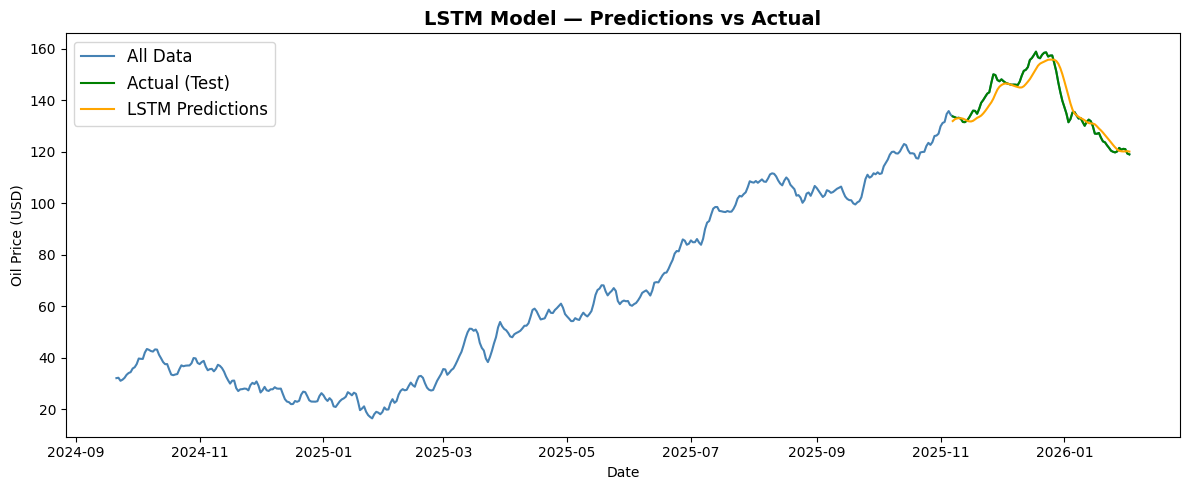

In [ ]:
# ============================================================
# RETRAIN LSTM WITH BEST HYPERPARAMETERS
# Use best units and batch_size found in tuning step
# ============================================================

best_units      = int(best_params['units'])
best_batch_size = int(best_params['batch_size'])

print(f'Retraining with units={best_units}, batch_size={best_batch_size}')

# retrain with best hyperparameters
best_lstm_model, best_history = build_lstm_model(
    train_X, train_y,
    test_X,  test_y,
    epochs=50,
    batch_size=best_batch_size
)

# re-evaluate with best model
inv_yhat, inv_y, lstm_rmse = evaluate_lstm(data, best_lstm_model, scaler,
                                            test_X, test_y, n_train)

**24 Month Forcast with confidence intervals**

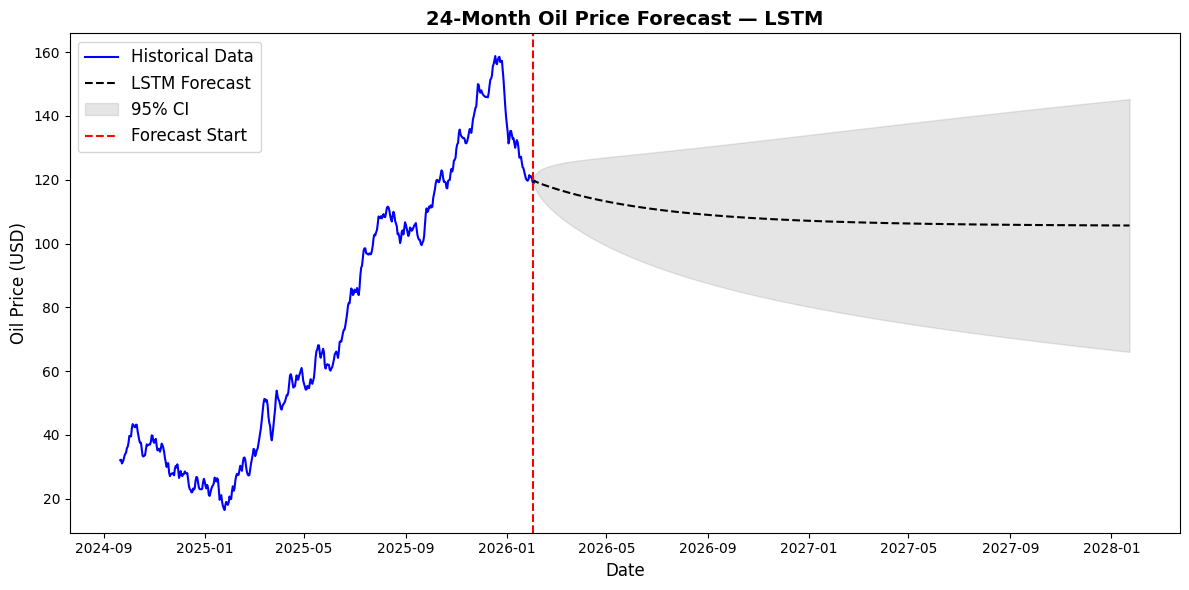

Last known price : $118.92
Forecast end     : $105.66
95% CI end       : [66.05, 145.28]


In [ ]:
# ============================================================
# 24-MONTH LSTM FORECAST — SIMPLE WORKING VERSION
# Clean recursive forecast with confidence intervals
# built from training residuals
# ============================================================

from scipy.ndimage import uniform_filter1d

def lstm_forecast(data, best_lstm_model, scaler,
                  n_forecast=720, lookback=60, column='price'):
    """
    Simple clean LSTM forecast.
    CI built from model's training error (RMSE).
    """
    last_prices = data[column].values[-lookback:]
    last_scaled = scaler.transform(
        last_prices.reshape(-1, 1)
    ).flatten()

    forecast_scaled = []
    current_window  = list(last_scaled)

    # single clean recursive forecast
    for _ in range(n_forecast):
        X_input     = np.array(
            current_window[-lookback:]
        ).reshape(1, lookback, 1).astype('float32')

        next_scaled = best_lstm_model.predict(
            X_input, verbose=0
        )[0][0]

        forecast_scaled.append(next_scaled)
        current_window.append(next_scaled)

    # invert scaling
    forecast_prices = scaler.inverse_transform(
        np.array(forecast_scaled).reshape(-1, 1)
    ).flatten()

    # build CI from lstm_rmse — widens over time
    time_steps = np.arange(1, n_forecast + 1)
    ci_width   = lstm_rmse * np.sqrt(time_steps / 30)
    lower_ci   = forecast_prices - 1.96 * ci_width
    upper_ci   = forecast_prices + 1.96 * ci_width

    # create future dates
    last_date    = data[column].index[-1]
    future_dates = pd.date_range(
        start=last_date, periods=n_forecast + 1, freq='D'
    )[1:]

    connect_dates  = pd.DatetimeIndex([last_date]).append(future_dates)
    connect_values = np.append(data[column].iloc[-1], forecast_prices)
    connect_lower  = np.append(data[column].iloc[-1], lower_ci)
    connect_upper  = np.append(data[column].iloc[-1], upper_ci)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(data[column], color='blue', label='Historical Data')
    ax.plot(connect_dates, connect_values,
            color='black', linestyle='--', label='LSTM Forecast')
    ax.fill_between(connect_dates,
                    connect_lower, connect_upper,
                    color='grey', alpha=0.2, label='95% CI')
    ax.axvline(last_date, color='red', linestyle='--',
               linewidth=1.5, label='Forecast Start')
    ax.set_title('24-Month Oil Price Forecast — LSTM',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Oil Price (USD)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f'Last known price : ${data[column].iloc[-1]:.2f}')
    print(f'Forecast end     : ${forecast_prices[-1]:.2f}')
    print(f'95% CI end       : [{lower_ci[-1]:.2f}, {upper_ci[-1]:.2f}]')

    return future_dates, forecast_prices, lower_ci, upper_ci


future_dates, forecast_prices, lower_ci, upper_ci = lstm_forecast(
    data, best_lstm_model, scaler,
    lookback   = 60,
    n_forecast = 720
)